# Kakhnouski Yauheni 153503 Lab2-3

## Цели работ: 
### 1. Сгенерировать датасеты
### 2. Расчитать несмещенную дисперсию и матожидание
### 3. Построить доверительные интервалы
### 4. Подобрать теоретическое распределение 
  (метод максимального правдоподобия, метод наименьших квадратов, криетрий Колмогорова-Смирнова)
### 5. Проверить гипотезы о соответствии закона распределения имеющихся данных теоретическому распределению с помощью критерия Колмогорова


In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Функция генерации распределений (geometric, binomial, poisson, uniform, normal, exponential)

In [104]:
def generate_distributions(sample_size=1000):
    distributions = {
        'geometric': {'func': np.random.geometric, 'params': {'p': 0.3}},
        'binomial': {'func': np.random.binomial, 'params': {'n': 100, 'p': 0.5}},
        'poisson': {'func': np.random.poisson, 'params': {'lam': 20}},
        'uniform': {'func': np.random.uniform, 'params': {'low': 0, 'high': 10}},
        'normal': {'func': np.random.normal, 'params': {'loc': 0, 'scale': 3}},
        'exponential': {'func': np.random.exponential, 'params': {'scale': 1}}
    }

    generated_data = {}
    
    for dist_name, dist_info in distributions.items():
        params = dist_info['params']
        generated_data[dist_name] = dist_info['func'](size=sample_size, **params)
    
    return generated_data

# Генерация данных
generated_data = generate_distributions()

## Построение графиков распределений

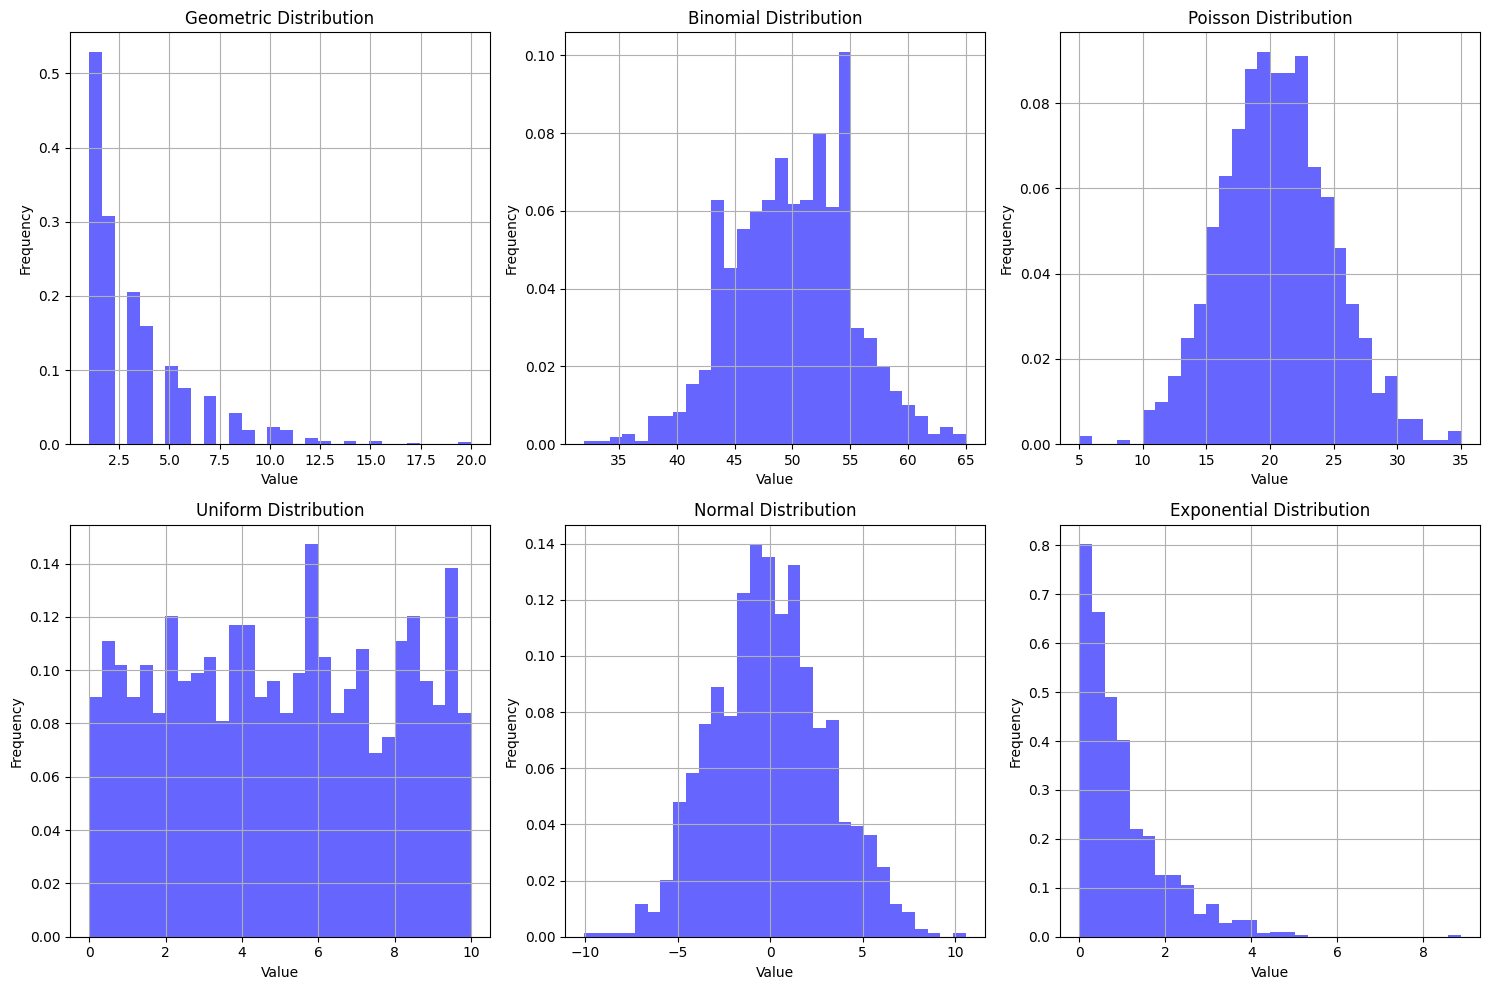

In [105]:
def plot_distributions(data):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.flatten()

    for i, (dist_name, sample_data) in enumerate(data.items()):
        ax = axs[i]
        ax.hist(sample_data, bins=30, density=True, alpha=0.6, color='b')
        ax.set_title(dist_name.capitalize() + ' Distribution')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Построение графиков распределений
plot_distributions(generated_data)

## Функции расчета мат. ожидания и несмещенной дисперсии

Математическое ожидание (математическое ожидание случайной величины) - это среднее значение, которое ожидается получить при повторении эксперимента или при сборе данных. Для дискретной случайной величины $X$ с функцией вероятности $P(X)$ математическое ожидание вычисляется следующим образом:

$$
E[X] = \sum_{x} x \cdot P(X = x)
$$

Для непрерывной случайной величины с плотностью вероятности $f(x)$, математическое ожидание выглядит следующим образом:

$$
E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx
$$

Несмещенная дисперсия - это мера разброса значений случайной величины относительно ее среднего значения. Для дискретной случайной величины $X$ с математическим ожиданием $\mu$, несмещенная дисперсия вычисляется следующим образом:

$$
Var(X) = \sum_{x} (x - \mu)^2 \cdot P(X = x)
$$

Для непрерывной случайной величины с математическим ожиданием $\mu$, несмещенная дисперсия выглядит так:

$$
Var(X) = \int_{-\infty}^{\infty} (x - \mu)^2 \cdot f(x) \, dx
$$


In [106]:
def calculate_mean_and_variance(data):
    results = {}
    for dist_name, sample_data in data.items():
        mean = np.mean(sample_data)
        variance = np.var(sample_data, ddof=1)  # Указываем ddof=1 для вычисления несмещенной дисперсии
        results[dist_name] = {'mean': mean, 'variance': variance}
    return results

def confidence_interval(data, num_intervals=1, confidence_level=0.95):
    n = len(data)
    mean, std_dev = np.mean(data), np.std(data, ddof=1)
    margin_of_error = stats.norm.ppf((1 + confidence_level) / 2) * (std_dev / np.sqrt(n))
    lower_bound = mean - margin_of_error
    upper_bound = mean + margin_of_error
    return [(lower_bound, upper_bound) for _ in range(num_intervals)]

# Вычисление математического ожидания и несмещенной дисперсии
results = calculate_mean_and_variance(generated_data)
for dist_name, values in results.items():
    print(f"{dist_name.capitalize()} Distribution:")
    print(f"  Mean: {values['mean']}")
    print(f"  Unbiased Variance: {values['variance']}\n")

confidence_level = 0.95
num_intervals = 10 # Количество доверительных интервалов
for dist_name, sample_data in generated_data.items():
    intervals = confidence_interval(sample_data, num_intervals, confidence_level)
    print(f"[{dist_name.capitalize()} Distribution] Confidence Intervals ({confidence_level*100}%): {intervals}")
    

Geometric Distribution:
  Mean: 3.278
  Unbiased Variance: 7.807

Binomial Distribution:
  Mean: 49.921
  Unbiased Variance: 26.103

Poisson Distribution:
  Mean: 20.023
  Unbiased Variance: 18.899

Uniform Distribution:
  Mean: 5.003
  Unbiased Variance: 8.324

Normal Distribution:
  Mean: 0.019
  Unbiased Variance: 9.246

Exponential Distribution:
  Mean: 1.022
  Unbiased Variance: 0.951

[Geometric Distribution] Confidence Intervals (95%): [(3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451), (3.105, 3.451)]
[Binomial Distribution] Confidence Intervals (95%): [(49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238), (49.604, 50.238)]
[Poisson Distribution] Confidence Intervals (95%): [(19.754, 20.292), (19.754, 20.292), (19.754, 20.292), (19.754, 20.292), (19.754, 20.292), (19.754, 20.292),

## Функции построения интервалов и подобранных распределений 

In [107]:
def plot_confidence_intervals(data, num_intervals=1, confidence_level=0.95):
    plt.figure(figsize=(15, 8))

    for dist_name, sample_data in data.items():
        intervals = confidence_interval(sample_data, num_intervals, confidence_level)
        for i, (lower_bound, upper_bound) in enumerate(intervals, start=1):
            plt.subplot(len(data), num_intervals, num_intervals * list(data.keys()).index(dist_name) + i)
            plt.hist(sample_data, bins=30, density=True, alpha=0.6, color='b')
            plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
            plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
            plt.title(f"{dist_name.capitalize()} Distribution\nInterval {i}")
            plt.xlabel('Value')
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_distribution_fits(data, fitted_distributions, xlim=(-10, 30)):
    plt.figure(figsize=(15, 8))

    for dist_name, sample_data in data.items():
        plt.subplot(2, 3, list(data.keys()).index(dist_name) + 1)

        # Построение гистограммы данных
        plt.hist(sample_data, bins=30, density=True, alpha=0.6, color='b', label='Data Histogram')

        # Построение функции распределения
        dist_info = fitted_distributions[dist_name]
        distribution = getattr(stats, dist_info['distribution'])
        params = dist_info['params']
        x = np.linspace(xlim[0], xlim[1], 1000)
        plt.plot(x, distribution.cdf(x, *params), 'r-', label='CDF')

        # Построение плотности вероятности
        plt.plot(x, distribution.pdf(x, *params), 'g--', label='PDF')

        plt.title(f"{dist_name.capitalize()} Distribution Fit")
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        plt.xlim(xlim)

    plt.tight_layout()
    plt.show()

## Функция подбора теоретичесих распределений

In [108]:
def fit_best_distribution(data):
    best_distribution = None
    best_params = None
    best_fit = float('inf')  # Начальное значение для наилучшего соответствия

    # Проходимся по всем распределениям в scipy.stats
    for distribution in dir(stats):
        # Игнорируем внутренние методы и классы
        if isinstance(getattr(stats, distribution), stats.rv_continuous):
            # Подгоняем распределение к данным
            try:
                params = getattr(stats, distribution).fit_loc_scale(data)
            except:
                try:
                    params = getattr(stats, distribution).fit_truncated(data)
                except:
                    continue

            # Вычисляем степень соответствия (чем меньше, тем лучше)
            fit = stats.kstest(data, distribution, args=params)[0]

            # Если это лучшее соответствие до сих пор, сохраняем его
            if fit < best_fit:
                best_distribution = distribution
                best_params = params
                best_fit = fit

    return best_distribution, best_params, best_fit

def fit_distributions_to_data(data):
    fitted_distributions = {}
    
    for dist_name, sample_data in data.items():
        best_distribution, best_params, best_fit = fit_best_distribution(sample_data)
        fitted_distributions[dist_name] = {'distribution': best_distribution, 'params': best_params, 'fit': best_fit}
    
    return fitted_distributions

## функция тестирования гипотез с помощью критерия Колмогорова-Смирнова

In [109]:
def test_hypothesis(data, fitted_distributions):
    for dist_name, dist_info in fitted_distributions.items():
        distribution = dist_info['distribution']
        params = dist_info['params']
        # диаграмма квантиль-квантиль
        # stats.probplot(data['normal'], dist='norm', plot=plt)
        # Получаем выборку для текущего распределения
        sample_data = data[dist_name]
    
        # Вычисляем статистику Колмогорова и p-значение
        kstest_result = stats.kstest(sample_data, distribution, args=params)
        ks_statistic, p_value = kstest_result
        
        # Выводим результаты
        print(f"For {dist_name.capitalize()} distribution:")
        print(f"KS Statistic: {ks_statistic}")
        print(f"P-value: {p_value}")
        if p_value > 0.05:
            print("Гипотеза не отвергается на уровне значимости 0.05\n")
        else:
            print("Гипотеза отвергается на уровне значимости 0.05\n")


KS-статистика вычисляется как наибольшее отклонение между эмпирической функцией распределения (ЭФР) и теоретической функцией распределения (ТФР) для данной выборки.

Эмпирическая функция распределения (ЭФР) - это функция, которая показывает, как часто значение из выборки не превышает определенное значение. Она строится путем упорядочивания значений выборки и подсчета доли значений, которые меньше или равны каждому значению.

Теоретическая функция распределения (ТФР) - это функция, которая описывает вероятность получить значение, не превышающее определенное значение, в предполагаемом распределении.

KS-статистика вычисляется как максимальная абсолютная разница между ЭФР и ТФР:

D = max |F_n(x) - F(x)|

где:
- F_n(x) - ЭФР для выборки,
- F(x) - ТФР для предполагаемого распределения.

Чтобы вычислить p-значение, мы используем распределение Колмогорова, которое представляет собой распределение максимальной разницы между эмпирической и теоретической функциями распределения. При нулевой гипотезе (гипотезе о том, что выборка подчиняется предполагаемому распределению), распределение KS-статистики стремится к распределению Колмогорова.

P-значение для теста Колмогорова-Смирнова вычисляется как вероятность получить такую же или большую KS-статистику (или такое же или большее отклонение) при условии, что нулевая гипотеза верна.

Это p-значение затем сравнивается с заранее выбранным уровнем значимости (обычно 0.05). Если p-значение меньше уровня значимости, то мы отвергаем нулевую гипотезу о соответствии выборки предполагаемому распределению. Если p-значение больше уровня значимости, то мы не можем отвергнуть нулевую гипотезу.


For Geometric distribution:
Best distribution: expon
Best parameters: (0.485, 2.793)

For Binomial distribution:
Best distribution: norm
Best parameters: (49.921, 5.107)

For Poisson distribution:
Best distribution: norm
Best parameters: (20.023, 4.345)

For Uniform distribution:
Best distribution: uniform
Best parameters: (0.008, 9.99)

For Normal distribution:
Best distribution: norm
Best parameters: (0.019, 3.039)

For Exponential distribution:
Best distribution: expon
Best parameters: (0.048, 0.975)



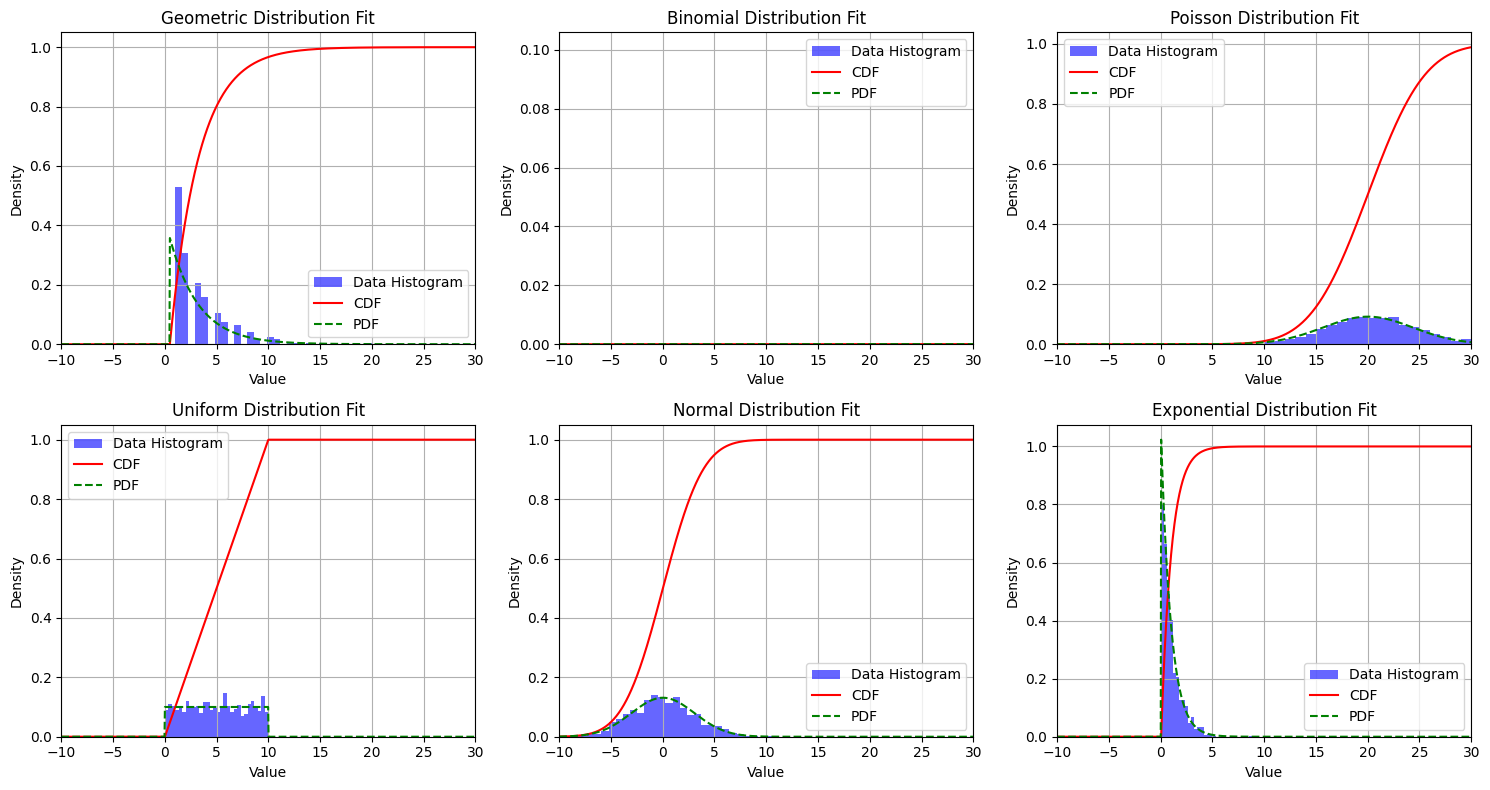

For Geometric distribution:
KS Statistic: 0.168
P-value: 3.1538617961709377e-25
Гипотеза отвергается на уровне значимости 0.05

For Binomial distribution:
KS Statistic: 0.054
P-value: 0.006
Гипотеза отвергается на уровне значимости 0.05

For Poisson distribution:
KS Statistic: 0.056
P-value: 0.004
Гипотеза отвергается на уровне значимости 0.05

For Uniform distribution:
KS Statistic: 0.018
P-value: 0.904
Гипотеза не отвергается на уровне значимости 0.05

For Normal distribution:
KS Statistic: 0.021
P-value: 0.768
Гипотеза не отвергается на уровне значимости 0.05

For Exponential distribution:
KS Statistic: 0.037
P-value: 0.128
Гипотеза не отвергается на уровне значимости 0.05



In [110]:
# Прогоним подгонку распределений для наших выборок
# print(generated_data)
fitted_distributions = fit_distributions_to_data(generated_data)

# Выведем результаты
for dist_name, dist_info in fitted_distributions.items():
    print(f"For {dist_name.capitalize()} distribution:")
    print(f"Best distribution: {dist_info['distribution']}")
    print(f"Best parameters: {dist_info['params']}\n")

# Построим функции распределения и плотности вероятности для каждого теоретического распределения
plot_distribution_fits(generated_data, fitted_distributions)

# Проверяем гипотезу для всех распределений из fitted_distributions
test_hypothesis(generated_data, fitted_distributions)